<a href="https://colab.research.google.com/github/wairiukoirwine/WEATHERPREDICIONMODEL/blob/main/HYBRIDWEATHERPREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as z:
        z.extractall('.')
        print(f"✅ Extracted: {z.namelist()}")

print("\nFiles available:", os.listdir('.'))

Saving archive (2).zip to archive (2).zip
✅ Extracted: ['weatherAUS.csv']

Files available: ['.config', 'weatherAUS.csv', 'archive (2).zip', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
df = pd.read_csv('weatherAUS.csv')

print(f"Dataset shape : {df.shape}")
print(f"Total records : {df.shape[0]:,}")
print(f"Total features: {df.shape[1]}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape : (145460, 23)
Total records : 145,460
Total features: 23

Columns:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

First 3 rows:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [4]:
print("Target — RainTomorrow:")
print(df['RainTomorrow'].value_counts())
print(f"\nMissing values in target: {df['RainTomorrow'].isnull().sum()}")
print(f"\nAll missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Target — RainTomorrow:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Missing values in target: 3267

All missing values per column:
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
dtype: int64


In [5]:
# Drop rows where target is missing
df = df.dropna(subset=['RainTomorrow'])

# Encode target: Yes = 1, No = 0
df['rain'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Select best numerical features
features = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am',
    'Pressure3pm', 'Cloud9am', 'Cloud3pm',
    'Temp9am', 'Temp3pm'
]

# Keep only selected features + target
df_clean = df[features + ['rain']].dropna()

print(f"Records after cleaning : {len(df_clean):,}")
print(f"Features used          : {len(features)}")
print(f"\nRain distribution:")
print(df_clean['rain'].value_counts())
print(f"\nRain rate: {df_clean['rain'].mean()*100:.1f}%")

Records after cleaning : 59,998
Features used          : 15

Rain distribution:
rain
0    46695
1    13303
Name: count, dtype: int64

Rain rate: 22.2%


In [6]:
# Create extra engineered features
df_clean = df_clean.copy()

df_clean['temp_range']       = df_clean['MaxTemp'] - df_clean['MinTemp']
df_clean['humidity_drop']    = df_clean['Humidity9am'] - df_clean['Humidity3pm']
df_clean['pressure_drop']    = df_clean['Pressure9am'] - df_clean['Pressure3pm']
df_clean['wind_avg']         = (df_clean['WindSpeed9am'] + df_clean['WindSpeed3pm']) / 2
df_clean['cloud_avg']        = (df_clean['Cloud9am'] + df_clean['Cloud3pm']) / 2
df_clean['temp_avg']         = (df_clean['Temp9am'] + df_clean['Temp3pm']) / 2

# Updated feature list
features_v2 = features + [
    'temp_range', 'humidity_drop', 'pressure_drop',
    'wind_avg', 'cloud_avg', 'temp_avg'
]

X = df_clean[features_v2]
y = df_clean['rain']

print(f"✅ Feature engineering done!")
print(f"Total features now: {len(features_v2)}")
print(f"Total records     : {len(X):,}")

✅ Feature engineering done!
Total features now: 21
Total records     : 59,998


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print("✅ Split and scaled!")

Training samples : 47,998
Testing  samples : 12,000
✅ Split and scaled!


In [8]:
model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
model.fit(X_train_scaled, y_train)

print("✅ Model trained!")
print(f"\nTop 5 most influential features (by coefficient):")
coef_df = pd.DataFrame({
    'feature': features_v2,
    'coefficient': model.coef_[0]
}).reindex(pd.Series(model.coef_[0]).abs().sort_values(ascending=False).index)

for _, row in coef_df.head(5).iterrows():
    direction = "↑ rain more likely" if row['coefficient'] > 0 else "↓ rain less likely"
    print(f"  {row['feature']:20s}: {row['coefficient']:+.4f}  {direction}")

✅ Model trained!

Top 5 most influential features (by coefficient):
  WindGustSpeed       : +0.8169  ↑ rain more likely
  Humidity3pm         : +0.7211  ↑ rain more likely
  Sunshine            : -0.5542  ↓ rain less likely
  Humidity9am         : +0.5219  ↑ rain more likely
  Temp9am             : +0.3161  ↑ rain more likely


In [10]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
acc    = accuracy_score(y_test, y_pred)

print(f"{'='*50}")
print(f"  ACCURACY : {acc*100:.2f}%")
print(f"  Test size: {len(y_test):,} records")
print(f"  Correct  : {int(acc*len(y_test)):,} predictions")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Rain','Rain']))

  ACCURACY : 85.68%
  Test size: 12,000 records
  Correct  : 10,282 predictions

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.88      0.94      0.91      9339
        Rain       0.74      0.55      0.63      2661

    accuracy                           0.86     12000
   macro avg       0.81      0.75      0.77     12000
weighted avg       0.85      0.86      0.85     12000



In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain','Rain'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Australia Weather\nAccuracy: {acc*100:.1f}%',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTrue Positives  (Rain caught)    : {cm[1][1]:,}")
print(f"True Negatives  (No Rain correct): {cm[0][0]:,}")
print(f"False Positives (False alarms)   : {cm[0][1]:,}")
print(f"False Negatives (Missed rain)    : {cm[1][0]:,}")

NameError: name 'y_pred' is not defined

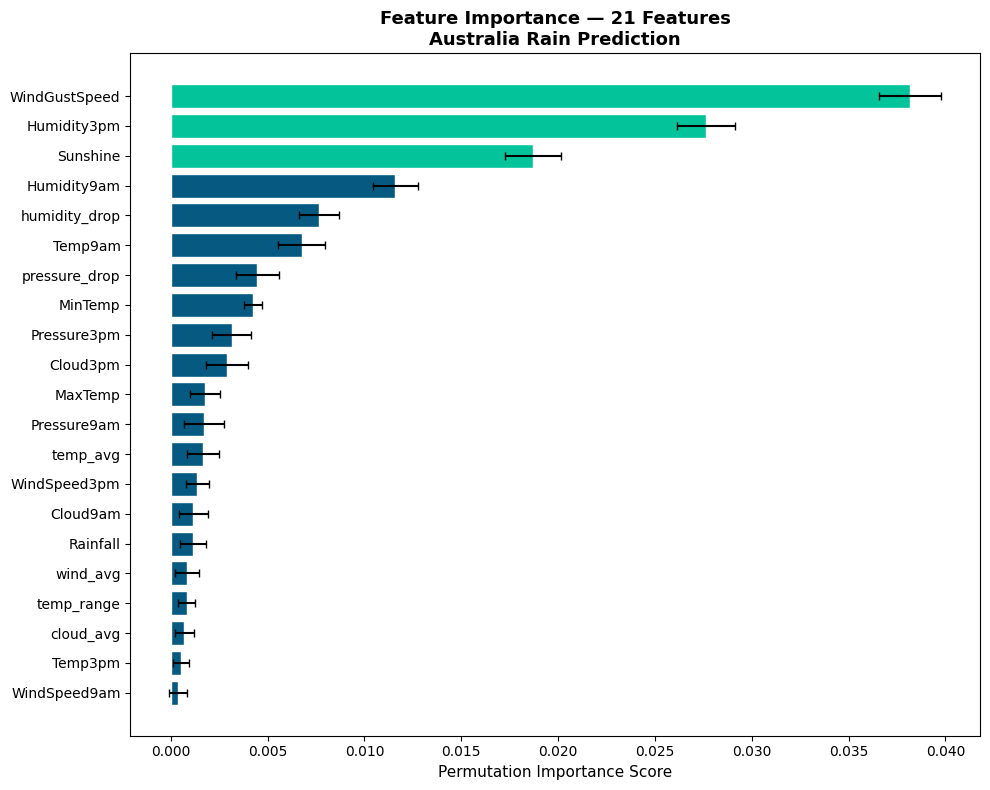


Top 3 predictors:
  WindGustSpeed       : 0.0382
  Humidity3pm         : 0.0276
  Sunshine            : 0.0187


In [11]:
pi = permutation_importance(
    model, X_test_scaled, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature'   : features_v2,
    'importance': pi.importances_mean,
    'std'       : pi.importances_std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#02C39A' if i >= len(importance_df)-3 else '#065A82'
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['feature'], importance_df['importance'],
                xerr=importance_df['std'], color=colors,
                edgecolor='white', capsize=3)
plt.xlabel('Permutation Importance Score', fontsize=11)
plt.title('Feature Importance — 21 Features\nAustralia Rain Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTop 3 predictors:")
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f}")

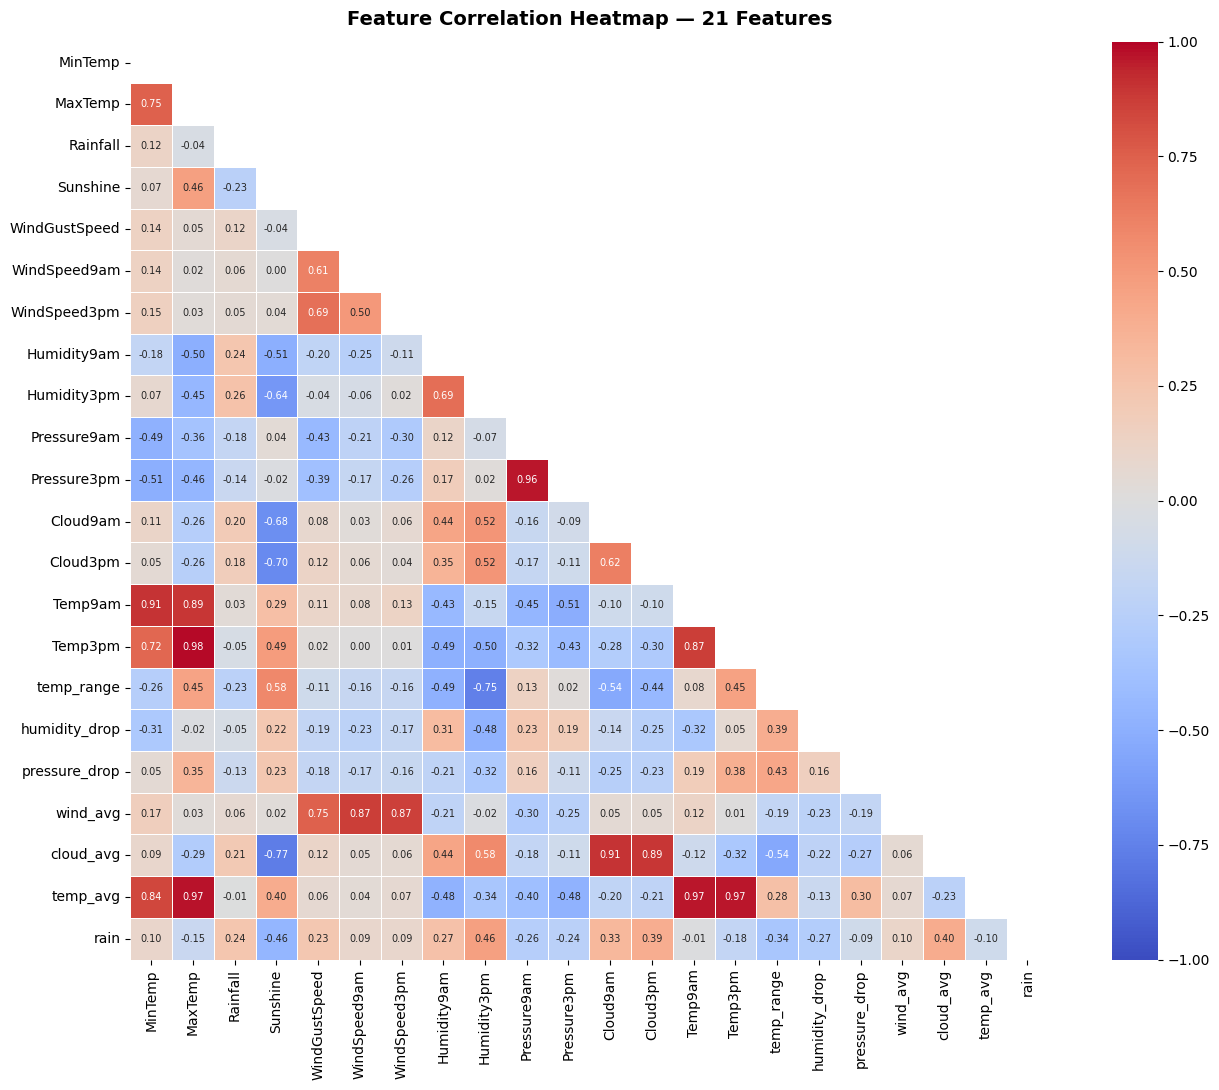

In [12]:
plt.figure(figsize=(14, 11))
corr = df_clean[features_v2 + ['rain']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, square=True, annot_kws={'size': 7},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap — 21 Features',
          fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

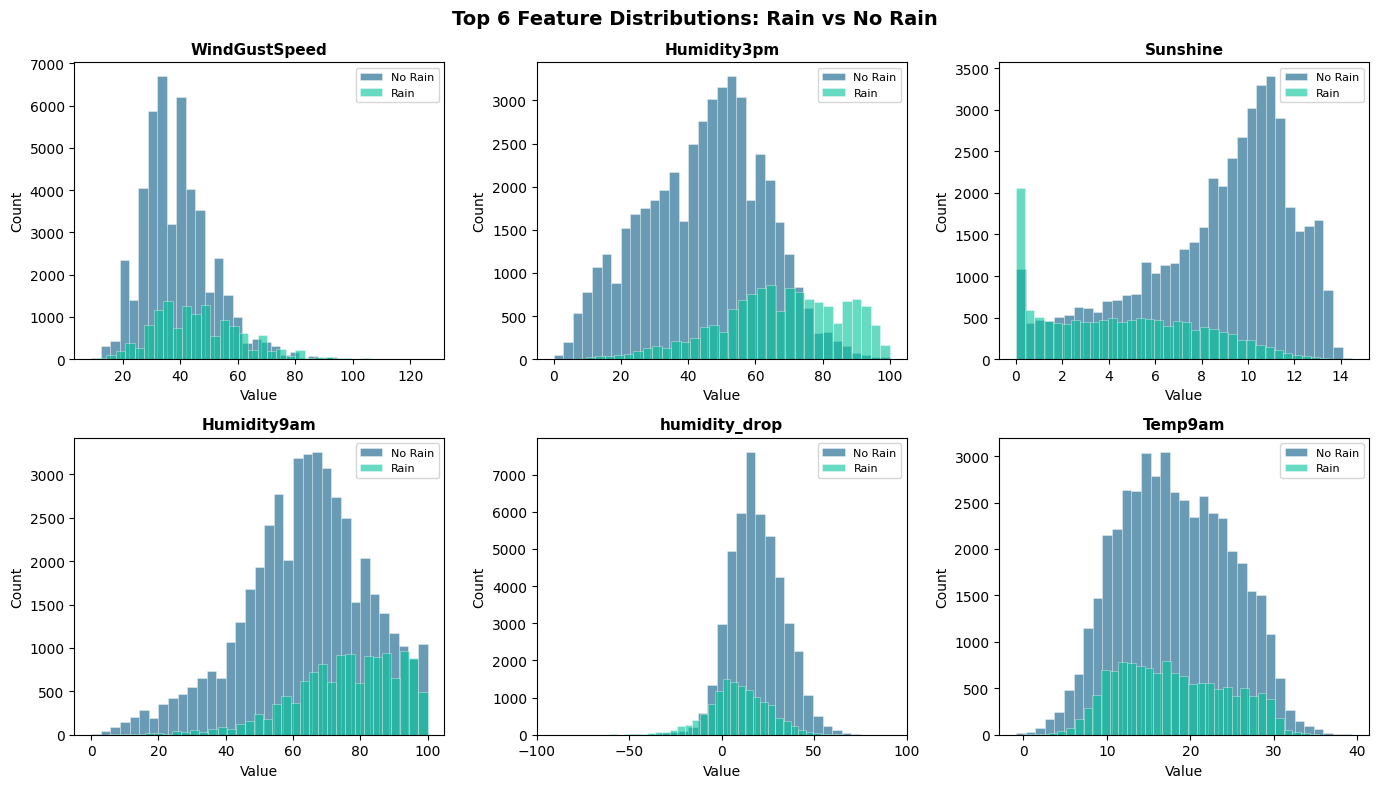

In [13]:
top_features = importance_df.tail(6)['feature'].tolist()[::-1]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Top 6 Feature Distributions: Rain vs No Rain',
             fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    for val, color, label in [(0,'#065A82','No Rain'),(1,'#02C39A','Rain')]:
        subset = df_clean[df_clean['rain'] == val][feat].dropna()
        ax.hist(subset, bins=35, alpha=0.6, color=color,
                label=label, edgecolor='white', linewidth=0.4)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

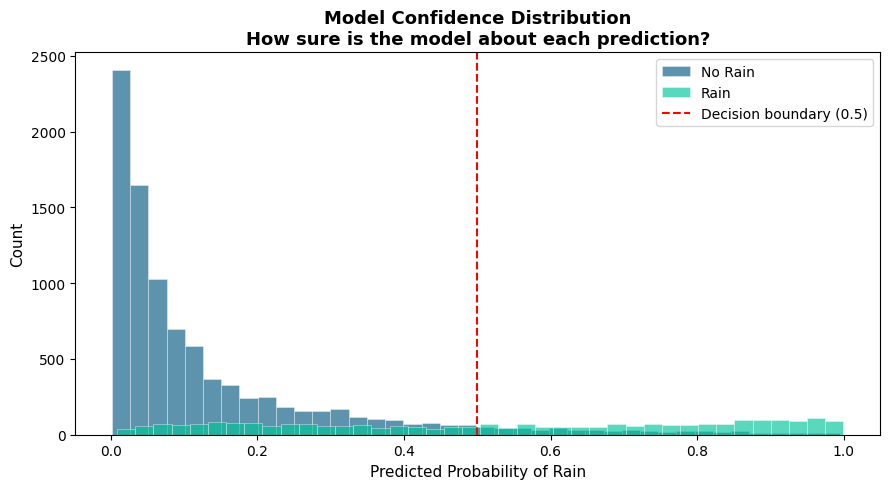

Predictions left of red line  → Model said No Rain
Predictions right of red line → Model said Rain


In [14]:
plt.figure(figsize=(9, 5))
for val, color, label in [(0,'#065A82','No Rain'),(1,'#02C39A','Rain')]:
    mask = y_test == val
    plt.hist(y_prob[mask], bins=40, alpha=0.65, color=color,
             label=label, edgecolor='white', linewidth=0.4)

plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
plt.xlabel('Predicted Probability of Rain', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Model Confidence Distribution\nHow sure is the model about each prediction?',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig5_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions left of red line  → Model said No Rain")
print("Predictions right of red line → Model said Rain")

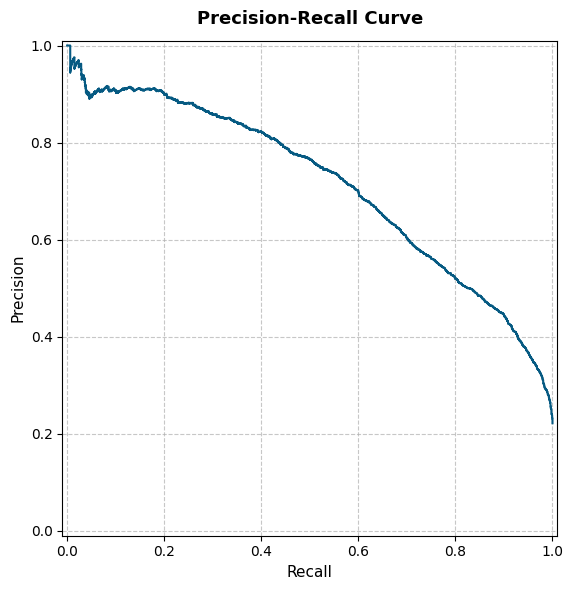

Area Under the Precision-Recall Curve (AUPRC): 0.7137


In [16]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot the Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 6))
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot(ax=ax, color='#065A82')

ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('fig6_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate Area Under the Precision-Recall Curve (AUPRC)
from sklearn.metrics import auc
auprc = auc(recall, precision)
print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc:.4f}")

In [15]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("=" * 55)
print("       FINAL PROJECT SUMMARY")
print("=" * 55)
print(f"  Dataset          : Rain in Australia")
print(f"  Total records    : {len(df_clean):,}")
print(f"  Features used    : {len(features_v2)} (15 original + 6 engineered)")
print(f"  Model            : Logistic Regression")
print(f"  Training samples : {len(X_train):,}")
print(f"  Testing  samples : {len(X_test):,}")
print(f"  Accuracy         : {acc*100:.2f}%")
print(f"  AUC-ROC Score    : {auc:.4f}")
print(f"  Correct preds    : {int(acc*len(y_test)):,} / {len(y_test):,}")
print("=" * 55)
print("  Charts saved:")
print("  fig1 — Confusion Matrix")
print("  fig2 — Feature Importance (21 features)")
print("  fig3 — Correlation Heatmap")
print("  fig4 — Top 6 Feature Distributions")
print("  fig5 — Probability Distribution")
print("=" * 55)
print("✅ Project complete!")

       FINAL PROJECT SUMMARY
  Dataset          : Rain in Australia
  Total records    : 59,998
  Features used    : 21 (15 original + 6 engineered)
  Model            : Logistic Regression
  Training samples : 47,998
  Testing  samples : 12,000
  Accuracy         : 85.68%
  AUC-ROC Score    : 0.8842
  Correct preds    : 10,282 / 12,000
  Charts saved:
  fig1 — Confusion Matrix
  fig2 — Feature Importance (21 features)
  fig3 — Correlation Heatmap
  fig4 — Top 6 Feature Distributions
  fig5 — Probability Distribution
✅ Project complete!
